# MODELING NOTEBOOK
This notebook is to document my modeling process and is for me to get a feel for how to model with my chosen lagged variables.

## Import necessary libraries

In [2]:
import pandas as pd
import numpy as np
import pickle

## Import the .pkl file containing the lagged feature data

In [4]:
with open("data/MODELING_FEATURE_NAMES/top_features_openings.pkl", "rb") as f:
    top_features_openings = pickle.load(f)

with open("data/MODELING_FEATURE_NAMES/top_features_layoffs.pkl", "rb") as f:
    top_features_layoffs = pickle.load(f)

In [5]:
top_features_openings

{'Job Openings: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)': [{'lag': 0,
   'top_features': {'Hires: State and local government, excluding education - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)': np.float64(0.7005101614036647),
    'Hires: Total nonfarm in South Carolina - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)': np.float64(0.655223512331025),
    'Quits: Private educational services - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)': np.float64(0.6478137598666164),
    'Hires: State and local government education - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)': np.float64(0.6239317604219325),
    'Hires: Construction - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)': np.float64(-0.621695060090696),
    'Hires: Total nonfarm in Tennessee - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)': np.float64(0.6041980168349715),
    'Hires

## Import the datasets that we will pull the features from

In [13]:
openings_X = pd.read_csv("data/reduced/openings_X_data.csv")
openings_y = pd.read_csv("data/labels/openings_y_data.csv")
layoffs_X = pd.read_csv("data/reduced/layoffs_X_data.csv")
layoffs_y = pd.read_csv("data/labels/layoffs_y_data.csv")

## PLAY AROUND WITH MODELING FOR A LITTLE BIT

In [8]:
%pip install statsmodels

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\samee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [9]:
%pip install joblib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\samee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [16]:
import pandas as pd
import joblib
from statsmodels.tsa.statespace.sarimax import SARIMAX

label = 'Job Openings: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)'
lagged_entries = top_features_openings[label]

for entry in lagged_entries:
    lag = entry['lag']
    top_features = list(entry['top_features'].keys())

    # Shift label and feature data
    y_lagged = openings_y[label].shift(-lag)
    X_lagged = openings_X[top_features].shift(-lag)

    # Align and drop NaNs
    aligned = pd.concat([y_lagged.rename(label), X_lagged], axis=1).dropna()
    y_aligned = aligned[label]
    X_aligned = aligned[top_features]

    # Train ARIMA model
    model = SARIMAX(y_aligned, exog=X_aligned, order=(1, 1, 1))
    results = model.fit(disp=False)

    # Save model
    filename = f"models/openings/arima_test_{label.replace(' ', '_')}_lag{lag}.pkl"
    joblib.dump(results, filename)

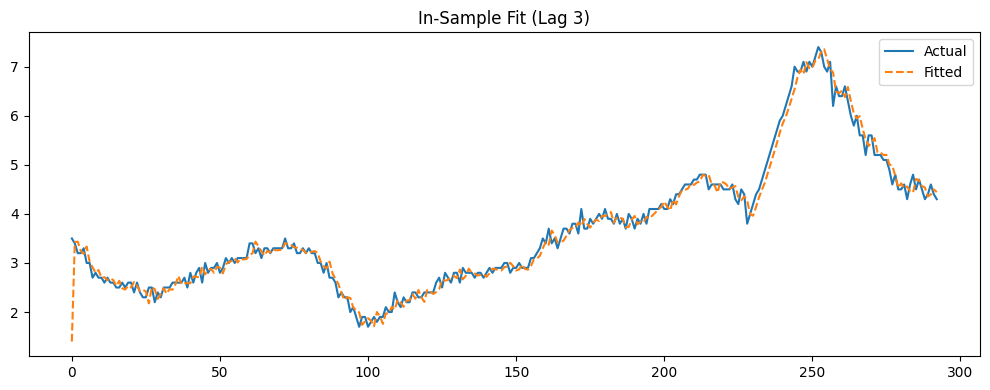

In [17]:
import matplotlib.pyplot as plt

# In-sample prediction
pred = results.predict(start=0, end=len(y_aligned)-1, exog=X_aligned)

plt.figure(figsize=(10, 4))
plt.plot(y_aligned.index, y_aligned, label='Actual')
plt.plot(y_aligned.index, pred, label='Fitted', linestyle='--')
plt.title(f'In-Sample Fit (Lag {lag})')
plt.legend()
plt.tight_layout()
plt.show()

In [19]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_aligned, pred)
rmse = mean_squared_error(y_aligned, pred)

print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

MAE: 0.1325
RMSE: 0.0411


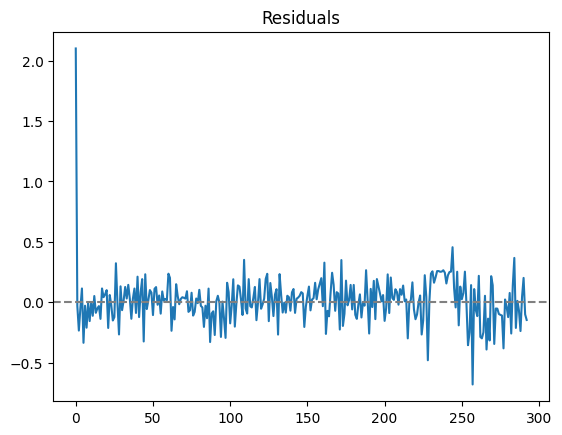

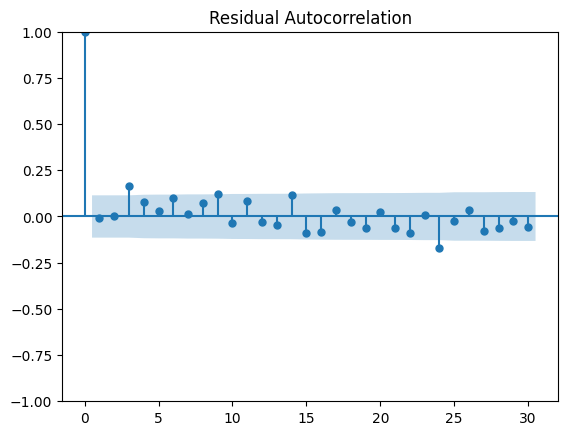

In [20]:
residuals = y_aligned - pred

# Plot residuals
residuals.plot(title='Residuals')
plt.axhline(0, color='gray', linestyle='--')
plt.show()

# ACF plot
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(residuals, lags=30)
plt.title('Residual Autocorrelation')
plt.show()

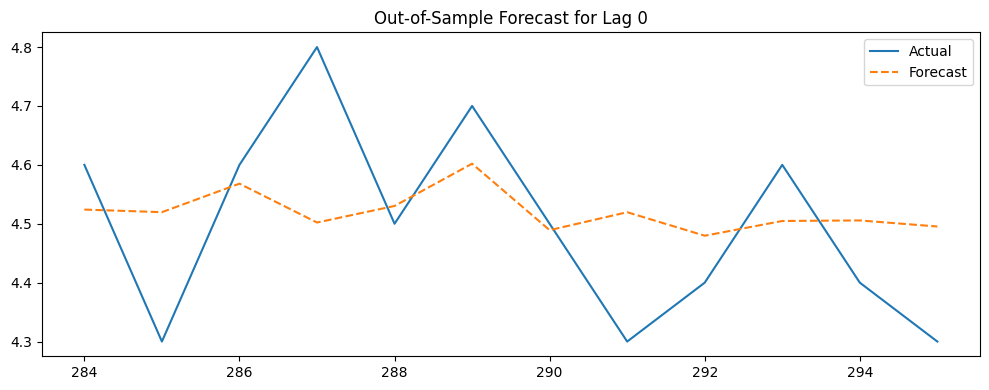

Lag 0 — MAE: 0.1217, RMSE: 0.0223


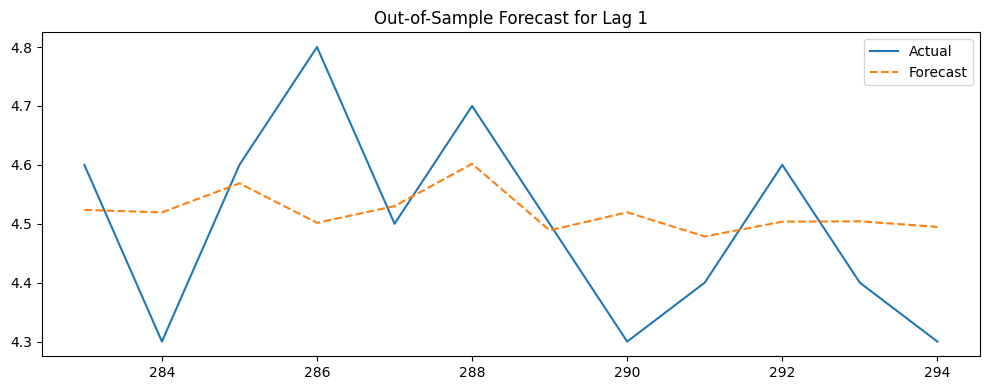

Lag 1 — MAE: 0.1215, RMSE: 0.0222


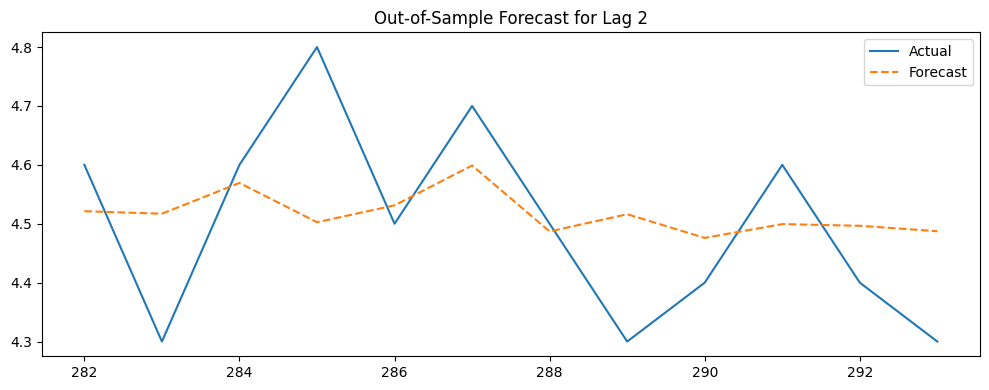

Lag 2 — MAE: 0.1205, RMSE: 0.0218


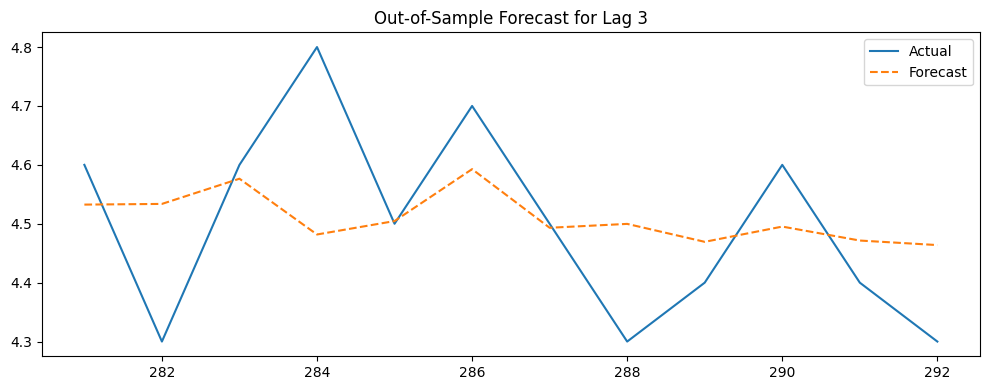

Lag 3 — MAE: 0.1142, RMSE: 0.0217


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Choose one label to test
label = 'Job Openings: Total nonfarm - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)'
lagged_entries = top_features_openings[label]

# Forecast horizon (e.g., last 3 months)
forecast_horizon = 12

# Full label series
y_full = openings_y[label]

for entry in lagged_entries:
    lag = entry['lag']
    top_features = list(entry['top_features'].keys())

    # Full feature matrix
    X_full = openings_X[top_features]

    # Shift label and features backward by lag
    y_lagged = y_full.shift(-lag)
    X_lagged = X_full.shift(-lag)

    # Drop rows with NaNs
    aligned = pd.concat([y_lagged.rename(label), X_lagged], axis=1).dropna()
    y_aligned = aligned[label]
    X_aligned = aligned[top_features]

    # Split into training and test sets
    y_train = y_aligned.iloc[:-forecast_horizon]
    y_test = y_aligned.iloc[-forecast_horizon:]
    X_train = X_aligned.iloc[:-forecast_horizon]
    X_test = X_aligned.iloc[-forecast_horizon:]

    # Train SARIMAX model
    model = SARIMAX(y_train, exog=X_train, order=(1, 1, 1))
    results = model.fit(disp=False)

    # Forecast
    forecast = results.predict(start=len(y_train), end=len(y_aligned)-1, exog=X_test)

    # Plot actual vs forecast
    plt.figure(figsize=(10, 4))
    plt.plot(y_test.index, y_test, label='Actual')
    plt.plot(y_test.index, forecast, label='Forecast', linestyle='--')
    plt.title(f'Out-of-Sample Forecast for Lag {lag}')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Print error metrics
    mae = mean_absolute_error(y_test, forecast)
    rmse = mean_squared_error(y_test, forecast)
    print(f"Lag {lag} — MAE: {mae:.4f}, RMSE: {rmse:.4f}")

    # Optionally save model
    filename = f"models/openings/arima_forecast_test_{label.replace(' ', '_')}_lag{lag}.pkl"
    joblib.dump(results, filename)

Look into MAE vs MAPE

## START MODELING WITH ARIMA FOR ALL LABELS IN OPENINGS DATASET
Here, I will create models for all the labels in the job openings dataset. I'm holding off on doing the layoffs one for a bit, but that will come later after I'm done getting used to modeling with ARIMA, XGBoost, and Prophet and comparing their results.

In [66]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Store evaluation results
results_summary = []

# Forecast horizon (e.g., last 3 months)
forecast_horizon = 3

# Loop over all labels and lags
for label, lagged_entries in top_features_openings.items():
    y_full = openings_y[label]

    for entry in lagged_entries:
        lag = entry['lag']
        top_features = list(entry['top_features'].keys())
        X_full = openings_X[top_features]

        # Shift label and features backward by lag
        y_lagged = y_full.shift(-lag)
        X_lagged = X_full.shift(-lag)

        # Align and drop NaNs
        aligned = pd.concat([y_lagged.rename(label), X_lagged], axis=1).dropna()
        y_aligned = aligned[label]
        X_aligned = aligned[top_features]

        # Skip if not enough data
        if len(y_aligned) <= forecast_horizon + 10:
            print(f"Skipping {label} lag {lag} — not enough data")
            continue

        # Split into training and test sets
        y_train = y_aligned.iloc[:-forecast_horizon]
        y_test = y_aligned.iloc[-forecast_horizon:]
        X_train = X_aligned.iloc[:-forecast_horizon]
        X_test = X_aligned.iloc[-forecast_horizon:]

        # Train AutoARIMA model
        try:
            model = auto_arima(
                y_train,
                exogenous=X_train,
                seasonal=False,          # disable seasonality unless you need it
                stepwise=True,           # heuristic search for speed
                suppress_warnings=True,  # suppress convergence warnings
                error_action="ignore",   # ignore failed fits
                max_order=10             # limit complexity
            )
        except Exception as e:
            print(f"Model failed for {label} lag {lag}: {e}")
            continue

        # Forecast
        try:
            forecast = model.predict(n_periods=forecast_horizon, exogenous=X_test)
        except Exception as e:
            print(f"Forecast failed for {label} lag {lag}: {e}")
            continue

        # Compute error metrics
        mae = mean_absolute_error(y_test, forecast)
        rmse = np.sqrt(mean_squared_error(y_test, forecast))

        # Save model
        safe_label = label.replace(" ", "_").replace(":", "").replace(",", "").replace("-", "").replace("/", "_")
        filename = f"models_arima/openings/arima_{safe_label}_lag{lag}.pkl"
        joblib.dump(model, filename)

        # Store results (including chosen order for transparency)
        results_summary.append({
            "label": label,
            "lag": lag,
            "mae": mae,
            "rmse": rmse,
            "order": model.order,        # (p,d,q) chosen by auto_arima
            "model_path": filename
        })

        # # Optional: plot forecast vs actual
        # plt.figure(figsize=(8, 3))
        # plt.plot(y_test.index, y_test, label='Actual')
        # plt.plot(y_test.index, forecast, label='Forecast', linestyle='--')
        # plt.title(f'{label} — Lag {lag}')
        # plt.legend()
        # plt.tight_layout()
        # plt.show()

# Convert results to DataFrame
results_df = pd.DataFrame(results_summary)
results_df = results_df.sort_values(by=["label", "lag"]).reset_index(drop=True)

# Display summary
print("\n📊 Model Evaluation Summary:")
print(results_df)


📊 Model Evaluation Summary:
                                                 label  lag       mae  \
0    Job Openings: Accommodation and food services ...    0  1.175107   
1    Job Openings: Accommodation and food services ...    1  1.168088   
2    Job Openings: Accommodation and food services ...    2  1.153777   
3    Job Openings: Accommodation and food services ...    3  1.166908   
4    Job Openings: Arts, entertainment, and recreat...    0  1.020912   
..                                                 ...  ...       ...   
131  Job Openings: Transportation, warehousing, and...    3  0.539877   
132  Job Openings: Wholesale trade - Rate in Percen...    0  0.559532   
133  Job Openings: Wholesale trade - Rate in Percen...    1  0.572327   
134  Job Openings: Wholesale trade - Rate in Percen...    2  0.556074   
135  Job Openings: Wholesale trade - Rate in Percen...    3  0.541553   

         rmse      order                                         model_path  
0    1.275708  (

In [67]:
results_df.to_csv("models_arima/openings/arima_evaluation_summary.csv", index=False)

In [68]:
results_df.groupby("label").apply(lambda df: df.nsmallest(1, "rmse"))

C:\Users\samee\AppData\Local\Temp\ipykernel_17004\53326753.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_df.groupby("label").apply(lambda df: df.nsmallest(1, "rmse"))


,,label,lag,mae,rmse,order,model_path
label,,,,,,,
"Job Openings: Accommodation and food services - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",2,Job Openings: Accommodation and food services ...,2,1.153777,1.258159,"(3, 1, 2)",models_arima/openings/arima_Job_Openings_Accom...
"Job Openings: Arts, entertainment, and recreation - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",6,"Job Openings: Arts, entertainment, and recreat...",2,1.022566,1.183737,"(0, 1, 2)",models_arima/openings/arima_Job_Openings_Arts_...
"Job Openings: Construction - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",9,"Job Openings: Construction - Rate in Percent, ...",1,0.296020,0.348917,"(2, 1, 2)",models_arima/openings/arima_Job_Openings_Const...
"Job Openings: Durable goods manufacturing - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",15,Job Openings: Durable goods manufacturing - Ra...,3,0.315107,0.341366,"(2, 1, 3)",models_arima/openings/arima_Job_Openings_Durab...
"Job Openings: Federal - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",16,"Job Openings: Federal - Rate in Percent, Month...",0,0.545500,0.647302,"(0, 1, 1)",models_arima/openings/arima_Job_Openings_Feder...
"Job Openings: Finance and insurance - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",21,Job Openings: Finance and insurance - Rate in ...,1,0.550950,0.700700,"(0, 1, 1)",models_arima/openings/arima_Job_Openings_Finan...
"Job Openings: Financial activities - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",27,Job Openings: Financial activities - Rate in P...,3,0.471160,0.513592,"(0, 1, 1)",models_arima/openings/arima_Job_Openings_Finan...
"Job Openings: Government - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",29,"Job Openings: Government - Rate in Percent, Mo...",1,0.166547,0.213533,"(2, 1, 3)",models_arima/openings/arima_Job_Openings_Gover...
"Job Openings: Health care and social assistance - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",32,Job Openings: Health care and social assistanc...,0,0.544290,0.622875,"(2, 1, 2)",models_arima/openings/arima_Job_Openings_Healt...


## START MODELING WITH AUTO-ARIMA FOR LAYOFFS DATASET

In [61]:
%pip install pmdarima

Defaulting to user installation because normal site-packages is not writeable
  Using cached urllib3-2.5.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
   ---------------------------------------- 0.0/711.9 kB ? eta -:--:--
   ----------------------------- ---------- 524.3/711.9 kB 3.5 MB/s eta 0:00:01
   ---------------------------------------- 711.9/711.9 kB 3.3 MB/s  0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ----------- ---------------------------- 0.8/2.8 MB 4.9 MB/s eta 0:00:01
   ---------------------- ----------------- 1.6/2.8 MB 4.3 MB/s eta 0:00:01
   ---------------------------------------- 2.8/2.8 MB 4.7 MB/s  0:00:00
Using cached setuptools-80.9.0-py3-none-any.whl (1.2 MB)
Using cached urllib3-2.5.0-py3-none-any.whl (129 kB)

   ---------------------------------------- 0/4 [urllib3]
   ---------------------------------------- 0/4 [urllib3]
   --------------------------------------


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\samee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [62]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Store evaluation results
results_summary_L = []

# Forecast horizon (e.g., last 3 months)
forecast_horizon = 3

# Loop over all labels and lags
for label, lagged_entries in top_features_layoffs.items():
    y_full = layoffs_y[label]

    for entry in lagged_entries:
        lag = entry['lag']
        top_features = list(entry['top_features'].keys())
        X_full = layoffs_X[top_features]

        # Shift label and features backward by lag
        y_lagged = y_full.shift(-lag)
        X_lagged = X_full.shift(-lag)

        # Align and drop NaNs
        aligned = pd.concat([y_lagged.rename(label), X_lagged], axis=1).dropna()
        y_aligned = aligned[label]
        X_aligned = aligned[top_features]

        # Skip if not enough data
        if len(y_aligned) <= forecast_horizon + 10:
            print(f"Skipping {label} lag {lag} — not enough data")
            continue

        # Split into training and test sets
        y_train = y_aligned.iloc[:-forecast_horizon]
        y_test = y_aligned.iloc[-forecast_horizon:]
        X_train = X_aligned.iloc[:-forecast_horizon]
        X_test = X_aligned.iloc[-forecast_horizon:]

        # Train auto_arima model
        try:
            model = auto_arima(
                y_train,
                exogenous=X_train,
                seasonal=False,
                stepwise=True,
                suppress_warnings=True,
                error_action="ignore",
                max_order=10
            )
        except Exception as e:
            print(f"Model failed for {label} lag {lag}: {e}")
            continue

        # Forecast
        try:
            forecast = model.predict(n_periods=forecast_horizon, exogenous=X_test)
        except Exception as e:
            print(f"Forecast failed for {label} lag {lag}: {e}")
            continue

        # Compute error metrics
        mae = mean_absolute_error(y_test, forecast)
        rmse = np.sqrt(mean_squared_error(y_test, forecast))

        # Save model
        safe_label = label.replace(" ", "_").replace(":", "").replace(",", "").replace("-", "").replace("/", "_")
        filename = f"models_arima/layoffs/arima_{safe_label}_lag{lag}.pkl"
        joblib.dump(model, filename)

        # Store results
        results_summary_L.append({
            "label": label,
            "lag": lag,
            "mae": mae,
            "rmse": rmse,
            "model_path": filename
        })

        # Optional: plot forecast vs actual
        # plt.figure(figsize=(8, 3))
        # plt.plot(y_test.index, y_test, label='Actual')
        # plt.plot(y_test.index, forecast, label='Forecast', linestyle='--')
        # plt.title(f'{label} — Lag {lag}')
        # plt.legend()
        # plt.tight_layout()
        # plt.show()

# Convert results to DataFrame (FIXED to use results_summary_L)
results_df_L = pd.DataFrame(results_summary_L)
results_df_L = results_df_L.sort_values(by=["label", "lag"]).reset_index(drop=True)

# Display summary
print("\n📊 Model Evaluation Summary:")
print(results_df_L)


📊 Model Evaluation Summary:
                                                 label  lag       mae  \
0    Layoffs and Discharges: Accommodation and food...    0  0.472278   
1    Layoffs and Discharges: Accommodation and food...    1  0.474190   
2    Layoffs and Discharges: Accommodation and food...    2  0.473084   
3    Layoffs and Discharges: Accommodation and food...    3  0.652991   
4    Layoffs and Discharges: Arts, entertainment, a...    0  0.223283   
..                                                 ...  ...       ...   
131  Layoffs and Discharges: Transportation, wareho...    3  0.073168   
132  Layoffs and Discharges: Wholesale trade - Rate...    0  0.163739   
133  Layoffs and Discharges: Wholesale trade - Rate...    1  0.164822   
134  Layoffs and Discharges: Wholesale trade - Rate...    2  0.164663   
135  Layoffs and Discharges: Wholesale trade - Rate...    3  0.167307   

         rmse                                         model_path  
0    0.482923  models_arima

In [64]:
results_df_L.to_csv("models_arima/layoffs/arima_evaluation_summary.csv", index=False)

In [65]:
results_df_L.groupby("label").apply(lambda df: df.nsmallest(1, "rmse"))

C:\Users\samee\AppData\Local\Temp\ipykernel_17004\4061579355.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_df_L.groupby("label").apply(lambda df: df.nsmallest(1, "rmse"))


,,label,lag,mae,rmse,model_path
label,,,,,,
"Layoffs and Discharges: Accommodation and food services - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",0,Layoffs and Discharges: Accommodation and food...,0,0.472278,0.482923,models_arima/layoffs/arima_Layoffs_and_Dischar...
"Layoffs and Discharges: Arts, entertainment, and recreation - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",5,"Layoffs and Discharges: Arts, entertainment, a...",1,0.223304,0.250617,models_arima/layoffs/arima_Layoffs_and_Dischar...
"Layoffs and Discharges: Construction - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",11,Layoffs and Discharges: Construction - Rate in...,3,0.237040,0.353614,models_arima/layoffs/arima_Layoffs_and_Dischar...
"Layoffs and Discharges: Durable goods manufacturing - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",12,Layoffs and Discharges: Durable goods manufact...,0,0.103646,0.117150,models_arima/layoffs/arima_Layoffs_and_Dischar...
"Layoffs and Discharges: Federal - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",16,Layoffs and Discharges: Federal - Rate in Perc...,0,0.094876,0.098872,models_arima/layoffs/arima_Layoffs_and_Dischar...
"Layoffs and Discharges: Finance and insurance - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",23,Layoffs and Discharges: Finance and insurance ...,3,0.258908,0.282518,models_arima/layoffs/arima_Layoffs_and_Dischar...
"Layoffs and Discharges: Financial activities - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",24,Layoffs and Discharges: Financial activities -...,0,0.331528,0.334674,models_arima/layoffs/arima_Layoffs_and_Dischar...
"Layoffs and Discharges: Government - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",31,Layoffs and Discharges: Government - Rate in P...,3,0.061052,0.067571,models_arima/layoffs/arima_Layoffs_and_Dischar...
"Layoffs and Discharges: Health care and social assistance - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",35,Layoffs and Discharges: Health care and social...,3,0.185886,0.190434,models_arima/layoffs/arima_Layoffs_and_Dischar...


## START MODELING WITH XGBOOST FOR OPENINGS DATASET
Basically doing the same thing that I did with the ARIMA model and seeing the performance of XGBoost relative to ARIMA

In [44]:
%pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\samee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [45]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

results_summary = []
forecast_horizon = 3

for label, lagged_entries in top_features_openings.items():
    y_full = openings_y[label]

    for entry in lagged_entries:
        lag = entry['lag']
        top_features = list(entry['top_features'].keys())
        X_full = openings_X[top_features]

        # Shift label and features backward by lag
        y_lagged = y_full.shift(-lag)
        X_lagged = X_full.shift(-lag)

        # Align and drop NaNs
        aligned = pd.concat([y_lagged.rename(label), X_lagged], axis=1).dropna()
        y_aligned = aligned[label]
        X_aligned = aligned[top_features]

        if len(y_aligned) <= forecast_horizon + 10:
            print(f"Skipping {label} lag {lag} — not enough data")
            continue

        # Split into training and test sets
        y_train = y_aligned.iloc[:-forecast_horizon]
        y_test = y_aligned.iloc[-forecast_horizon:]
        X_train = X_aligned.iloc[:-forecast_horizon]
        X_test = X_aligned.iloc[-forecast_horizon:]

        # Train XGBoost model
        model = xgb.XGBRegressor(n_estimators=100, max_depth=3, learning_rate=0.1)
        model.fit(X_train, y_train)

        # Forecast
        forecast = model.predict(X_test)

        # Evaluate
        mae = mean_absolute_error(y_test, forecast)
        rmse = np.sqrt(mean_squared_error(y_test, forecast))

        # Save model
        safe_label = label.replace(" ", "_").replace(":", "").replace(",", "").replace("-", "").replace("/", "_")
        filename = f"models_xgb/openings/xgb_{safe_label}_lag{lag}.pkl"
        joblib.dump(model, filename)

        # Store results
        results_summary.append({
            "label": label,
            "lag": lag,
            "mae": mae,
            "rmse": rmse,
            "model_path": filename
        })

        # # Optional: plot forecast vs actual
        # plt.figure(figsize=(8, 3))
        # plt.plot(y_test.index, y_test, label='Actual')
        # plt.plot(y_test.index, forecast, label='Forecast', linestyle='--')
        # plt.title(f'{label} — Lag {lag} (XGBoost)')
        # plt.legend()
        # plt.tight_layout()
        # plt.show()

# Convert results to DataFrame
results_df_xgb = pd.DataFrame(results_summary).sort_values(by=["label", "lag"]).reset_index(drop=True)
print("\n📊 XGBoost Model Evaluation Summary:")
print(results_df_xgb)


📊 XGBoost Model Evaluation Summary:
                                                 label  lag       mae  \
0    Job Openings: Accommodation and food services ...    0  1.257958   
1    Job Openings: Accommodation and food services ...    1  1.091973   
2    Job Openings: Accommodation and food services ...    2  1.145499   
3    Job Openings: Accommodation and food services ...    3  1.412531   
4    Job Openings: Arts, entertainment, and recreat...    0  0.783764   
..                                                 ...  ...       ...   
131  Job Openings: Transportation, warehousing, and...    3  1.006432   
132  Job Openings: Wholesale trade - Rate in Percen...    0  0.389908   
133  Job Openings: Wholesale trade - Rate in Percen...    1  0.408323   
134  Job Openings: Wholesale trade - Rate in Percen...    2  0.447050   
135  Job Openings: Wholesale trade - Rate in Percen...    3  0.433709   

         rmse                                         model_path  
0    1.413810  mode

In [47]:
results_df_xgb.to_csv("models_xgb/openings/xgb_evaluation_summary.csv", index=False)

In [57]:
results_df_xgb.groupby("label").apply(lambda df: df.nsmallest(1, "rmse"))

C:\Users\samee\AppData\Local\Temp\ipykernel_17004\553744564.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_df_xgb.groupby("label").apply(lambda df: df.nsmallest(1, "rmse"))


,,label,lag,mae,rmse,model_path
label,,,,,,
"Job Openings: Accommodation and food services - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",1,Job Openings: Accommodation and food services ...,1,1.091973,1.248818,models_xgb/openings/xgb_Job_Openings_Accommoda...
"Job Openings: Arts, entertainment, and recreation - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",4,"Job Openings: Arts, entertainment, and recreat...",0,0.783764,0.997708,models_xgb/openings/xgb_Job_Openings_Arts_ente...
"Job Openings: Construction - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",8,"Job Openings: Construction - Rate in Percent, ...",0,0.916131,1.024089,models_xgb/openings/xgb_Job_Openings_Construct...
"Job Openings: Durable goods manufacturing - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",14,Job Openings: Durable goods manufacturing - Ra...,2,0.406199,0.430918,models_xgb/openings/xgb_Job_Openings_Durable_g...
"Job Openings: Federal - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",16,"Job Openings: Federal - Rate in Percent, Month...",0,0.818995,1.009187,models_xgb/openings/xgb_Job_Openings_Federal__...
"Job Openings: Finance and insurance - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",23,Job Openings: Finance and insurance - Rate in ...,3,0.396549,0.474395,models_xgb/openings/xgb_Job_Openings_Finance_a...
"Job Openings: Financial activities - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",27,Job Openings: Financial activities - Rate in P...,3,0.310239,0.343791,models_xgb/openings/xgb_Job_Openings_Financial...
"Job Openings: Government - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",28,"Job Openings: Government - Rate in Percent, Mo...",0,0.264941,0.269266,models_xgb/openings/xgb_Job_Openings_Governmen...
"Job Openings: Health care and social assistance - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",33,Job Openings: Health care and social assistanc...,1,0.864376,0.899522,models_xgb/openings/xgb_Job_Openings_Health_ca...


## START MODELING WITH PROPHET FOR OPENINGS DATASET

In [48]:
%pip install prophet

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   ------------ --------------------------- 3.9/12.1 MB 20.1 MB/s eta 0:00:01
   --------------------------- ------------ 8.4/12.1 MB 20.6 MB/s eta 0:00:01
   -------------------------------------- - 11.5/12.1 MB 18.3 MB/s eta 0:00:01
   ---------------------------------------- 12.1/12.1 MB 17.5 MB/s  0:00:00
   ---------------------------------------- 0.0/1.3 MB ? eta -:--:--
   ---------------------------------------- 1.3/1.3 MB 7.1 MB/s  0:00:00

   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ---------------------------------------- 0/6 [tqdm]
   ------ --------------------------------- 1/6 [stanio]
   --------

ERROR: Could not install packages due to an OSError: [Errno 2] No such file or directory: 'C:\\Users\\samee\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python313\\site-packages\\prophet\\stan_model\\cmdstan-2.37.0\\stan\\lib\\stan_math\\lib\\tbb_2020.3\\include\\tbb\\internal\\_deprecated_header_message_guard.h'
HINT: This error might have occurred since this system does not have Windows Long Path support enabled. You can find information on how to enable this at https://pip.pypa.io/warnings/enable-long-paths


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: C:\Users\samee\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [55]:
import pandas as pd
import numpy as np
import joblib
import os
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt

# Store evaluation results
results_summary = []
forecast_horizon = 3

for label, lagged_entries in top_features_openings.items():
    y_full = openings_y[label].copy()

    # Ensure datetime index
    y_full.index = pd.to_datetime(y_full.index)
    y_full = y_full.sort_index()

    for entry in lagged_entries:
        lag = entry['lag']

        # Shift label by lag
        y_lagged = y_full.shift(-lag).dropna()

        # Format for Prophet
        df_prophet = pd.DataFrame({
            'ds': y_lagged.index,
            'y': y_lagged.values
        }).dropna()

        if len(df_prophet) <= forecast_horizon + 10:
            print(f"Skipping {label} lag {lag} — not enough data")
            continue

        # Split into training and test sets
        train_df = df_prophet.iloc[:-forecast_horizon]
        test_df = df_prophet.iloc[-forecast_horizon:]

        # Train Prophet model
        model = Prophet()
        model.fit(train_df)

        # Forecast on actual test dates
        future = pd.DataFrame({'ds': test_df['ds']})
        forecast = model.predict(future)

        # Extract predictions and actuals
        y_pred = forecast['yhat'].values
        y_true = test_df['y'].values

        # Evaluate
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))

        # Save model
        safe_label = label.replace(" ", "_").replace(":", "").replace(",", "").replace("-", "").replace("/", "_")
        filename = f"models_prophet/openings/prophet_{safe_label}_lag{lag}.pkl"
        joblib.dump(model, filename)

        # Store results
        results_summary.append({
            "label": label,
            "lag": lag,
            "mae": mae,
            "rmse": rmse,
            "model_path": filename
        })

        # # Plot forecast vs actual
        # plt.figure(figsize=(8, 3))
        # plt.plot(test_df['ds'], y_true, label='Actual')
        # plt.plot(test_df['ds'], y_pred, label='Forecast', linestyle='--')
        # plt.title(f'{label} — Lag {lag} (Prophet)')
        # plt.legend()
        # plt.tight_layout()
        # plt.show()

# Convert results to DataFrame
results_df_prophet = pd.DataFrame(results_summary)

if results_df_prophet.empty:
    print("⚠️ No Prophet models were successfully evaluated. Check for forecast date mismatches or data sparsity.")
else:
    results_df_prophet = results_df_prophet.sort_values(by=["label", "lag"]).reset_index(drop=True)
    print("\n📊 Prophet Model Evaluation Summary:")
    print(results_df_prophet)

00:59:58 - cmdstanpy - INFO - Chain [1] start processing
00:59:58 - cmdstanpy - INFO - Chain [1] done processing
00:59:58 - cmdstanpy - INFO - Chain [1] start processing
00:59:58 - cmdstanpy - INFO - Chain [1] done processing
00:59:59 - cmdstanpy - INFO - Chain [1] start processing
00:59:59 - cmdstanpy - INFO - Chain [1] done processing
00:59:59 - cmdstanpy - INFO - Chain [1] start processing
00:59:59 - cmdstanpy - INFO - Chain [1] done processing
00:59:59 - cmdstanpy - INFO - Chain [1] start processing
00:59:59 - cmdstanpy - INFO - Chain [1] done processing
00:59:59 - cmdstanpy - INFO - Chain [1] start processing
00:59:59 - cmdstanpy - INFO - Chain [1] done processing
00:59:59 - cmdstanpy - INFO - Chain [1] start processing
00:59:59 - cmdstanpy - INFO - Chain [1] done processing
00:59:59 - cmdstanpy - INFO - Chain [1] start processing
00:59:59 - cmdstanpy - INFO - Chain [1] done processing
01:00:00 - cmdstanpy - INFO - Chain [1] start processing
01:00:00 - cmdstanpy - INFO - Chain [1]


📊 Prophet Model Evaluation Summary:
                                                 label  lag       mae  \
0    Job Openings: Accommodation and food services ...    0  2.045184   
1    Job Openings: Accommodation and food services ...    1  2.022130   
2    Job Openings: Accommodation and food services ...    2  2.003510   
3    Job Openings: Accommodation and food services ...    3  1.994127   
4    Job Openings: Arts, entertainment, and recreat...    0  2.327631   
..                                                 ...  ...       ...   
131  Job Openings: Transportation, warehousing, and...    3  1.737372   
132  Job Openings: Wholesale trade - Rate in Percen...    0  1.519367   
133  Job Openings: Wholesale trade - Rate in Percen...    1  1.537957   
134  Job Openings: Wholesale trade - Rate in Percen...    2  1.531479   
135  Job Openings: Wholesale trade - Rate in Percen...    3  1.524629   

         rmse                                         model_path  
0    2.121476  mode

In [56]:
results_df_prophet.to_csv("models_prophet/openings/prophet_evaluation_summary.csv")

In [58]:
results_df_prophet.groupby("label").apply(lambda df: df.nsmallest(1, "rmse"))

C:\Users\samee\AppData\Local\Temp\ipykernel_17004\1637026950.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  results_df_prophet.groupby("label").apply(lambda df: df.nsmallest(1, "rmse"))


,,label,lag,mae,rmse,model_path
label,,,,,,
"Job Openings: Accommodation and food services - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",3,Job Openings: Accommodation and food services ...,3,1.994127,2.072111,models_prophet/openings/prophet_Job_Openings_A...
"Job Openings: Arts, entertainment, and recreation - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",6,"Job Openings: Arts, entertainment, and recreat...",2,2.326188,2.483081,models_prophet/openings/prophet_Job_Openings_A...
"Job Openings: Construction - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",8,"Job Openings: Construction - Rate in Percent, ...",0,1.603896,1.640413,models_prophet/openings/prophet_Job_Openings_C...
"Job Openings: Durable goods manufacturing - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",15,Job Openings: Durable goods manufacturing - Ra...,3,1.886797,1.904800,models_prophet/openings/prophet_Job_Openings_D...
"Job Openings: Federal - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",17,"Job Openings: Federal - Rate in Percent, Month...",1,1.298443,1.397737,models_prophet/openings/prophet_Job_Openings_F...
"Job Openings: Finance and insurance - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",22,Job Openings: Finance and insurance - Rate in ...,2,0.727141,0.799461,models_prophet/openings/prophet_Job_Openings_F...
"Job Openings: Financial activities - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",27,Job Openings: Financial activities - Rate in P...,3,0.865175,0.998522,models_prophet/openings/prophet_Job_Openings_F...
"Job Openings: Government - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",31,"Job Openings: Government - Rate in Percent, Mo...",3,1.163963,1.168930,models_prophet/openings/prophet_Job_Openings_G...
"Job Openings: Health care and social assistance - Rate in Percent, Monthly, Seasonally Adjusted (All size classes)",34,Job Openings: Health care and social assistanc...,2,2.154980,2.235779,models_prophet/openings/prophet_Job_Openings_H...


## Find the largest industries recorded in JOLTS

In [69]:
counts_sa = pd.read_csv("data/jolts_counts_seasonally_adjusted.csv")
counts_sa.shape

(296, 485)

In [70]:
industry_list = [
    "Total nonfarm",
    "Total private",
    "Mining and logging",
    "Construction",
    "Manufacturing",
    "Durable goods manufacturing",
    "Nondurable goods manufacturing",
    "Trade, transportation, and utilities",
    "Wholesale trade",
    "Retail trade",
    "Transportation, warehousing, and utilities",
    "Information",
    "Financial activities",
    "Finance and insurance",
    "Real estate and rental and leasing",
    "Professional and business services",
    "Private education and health services",
    "Private educational services",
    "Health care and social assistance",
    "Leisure and hospitality",
    "Arts, entertainment, and recreation",
    "Accommodation and food services",
    "Other services",
    "Government",
    "Federal",
    "State and local",
    "State and local government education",
    "State and local government, excluding education"
]

state_list = ['Alabama', 'Alaska', 'Arizona', 'Arkansas', 'California', 'Colorado', 'Connecticut', 'Delaware', 'District of Columbia', 'Florida', 'Georgia', 'Hawaii', 'Idaho', 'Illinois', 'Indiana', 'Iowa', 'Kansas', 'Kentucky', 'Louisiana', 'Maine', 'Maryland', 'Massachusetts', 'Michigan', 'Minnesota', 'Mississippi', 'Missouri', 'Montana', 'Nebraska', 'Nevada', 'New Hampshire', 'New Jersey', 'New Mexico', 'New York', 'North Carolina', 'North Dakota', 'Ohio', 'Oklahoma', 'Oregon', 'Pennsylvania', 'Rhode Island', 'South Carolina', 'South Dakota', 'Tennessee', 'Texas', 'Utah', 'Vermont', 'Virginia', 'Washington', 'West Virginia', 'Wisconsin', 'Wyoming']
region_list = ['Midwest region', 'Northeast region', 'South region', 'West region']


industry_job_openings = [col for col in counts_sa if "Job Openings:" in col and any(industry in col for industry in industry_list) and not any(state in col for state in state_list) and not any(region in col for region in region_list)]
for col in industry_job_openings:
    print(col)

Job Openings: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)
Job Openings: Total private - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)
Job Openings: Total private - Level in Thousands, Monthly, Seasonally Adjusted (1 to 9 employees)
Job Openings: Total private - Level in Thousands, Monthly, Seasonally Adjusted (10 to 49 employees)
Job Openings: Total private - Level in Thousands, Monthly, Seasonally Adjusted (50 to 249 employees)
Job Openings: Total private - Level in Thousands, Monthly, Seasonally Adjusted (250 to 999 employees)
Job Openings: Total private - Level in Thousands, Monthly, Seasonally Adjusted (1,000 to 4,999 employees)
Job Openings: Total private - Level in Thousands, Monthly, Seasonally Adjusted (5,000 or more employees)
Job Openings: Mining and logging - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)
Job Openings: Construction - Level in Thousands, Monthly, Seasonally Adjusted (All size c

In [71]:
counts_sa.head()

,Unnamed: 0,"Hires: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Job Openings: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Layoffs and Discharges: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Other separations: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Quits: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Total Separations: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Hires: Total nonfarm in Alabama - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Job Openings: Total nonfarm in Alabama - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Layoffs and Discharges: Total nonfarm in Alabama - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)",...,"Other separations: State and local government education - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Quits: State and local government education - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Total Separations: State and local government education - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Hires: State and local government, excluding education - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Job Openings: State and local government, excluding education - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Layoffs and Discharges: State and local government, excluding education - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Other separations: State and local government, excluding education - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Quits: State and local government, excluding education - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)","Total Separations: State and local government, excluding education - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)",date
0,0,5426.0,5088.0,2018.0,340.0,2882.0,5240.0,78.0,68.0,24.0,...,15.0,60.0,118.0,154.0,309.0,60.0,21.0,68.0,149.0,2000-12-01
1,1,5722.0,5234.0,2220.0,377.0,3245.0,5842.0,81.0,70.0,25.0,...,19.0,70.0,126.0,156.0,265.0,49.0,22.0,69.0,140.0,2001-01-01
2,2,5303.0,5097.0,1855.0,323.0,3053.0,5231.0,67.0,70.0,28.0,...,21.0,60.0,125.0,165.0,257.0,48.0,19.0,91.0,158.0,2001-02-01
3,3,5528.0,4762.0,2133.0,379.0,3054.0,5566.0,86.0,58.0,32.0,...,20.0,69.0,124.0,158.0,231.0,55.0,17.0,75.0,147.0,2001-03-01
4,4,5204.0,4615.0,1883.0,367.0,3163.0,5414.0,86.0,65.0,27.0,...,20.0,51.0,102.0,150.0,284.0,53.0,25.0,63.0,141.0,2001-04-01


In [73]:
# Sum job openings across all dates for each industry column
industry_openings_totals = counts_sa[industry_job_openings].sum().sort_values(ascending=False)

print(industry_openings_totals)

Job Openings: Total nonfarm - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)                                      1629366.0
Job Openings: Total private - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)                                      1464493.0
Job Openings: Total private - Level in Thousands, Monthly, Seasonally Adjusted (50 to 249 employees)                                    450550.0
Job Openings: Total private - Level in Thousands, Monthly, Seasonally Adjusted (10 to 49 employees)                                     395678.0
Job Openings: Private education and health services - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)               304480.0
Job Openings: Professional and business services - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)                  301708.0
Job Openings: Trade, transportation, and utilities - Level in Thousands, Monthly, Seasonally Adjusted (All size classes)          

In [74]:
# Convert results_summary into a DataFrame
results_df = pd.DataFrame(results_summary)

# Get top N industries by openings
top_industries = industry_openings_totals.head(10).index

# Normalize industry names (strip "Job Openings:" and other text)
top_industries_clean = [col.split(":")[1].split("-")[0].strip() for col in top_industries]

# Filter results_df for those industries with "Rate in Percent"
best_rate_models = results_df[
    results_df["label"].str.contains("Rate in Percent") &
    results_df["label"].str.contains("|".join(top_industries_clean))
]

# Sort by performance (e.g., lowest RMSE)
best_rate_models = best_rate_models.sort_values(by="rmse").reset_index(drop=True)

print(best_rate_models)

                                                label  lag       mae  \
0   Job Openings: Total private - Rate in Percent,...    0  0.085848   
1   Job Openings: Total private - Rate in Percent,...    1  0.085697   
2   Job Openings: Total private - Rate in Percent,...    3  0.085654   
3   Job Openings: Total private - Rate in Percent,...    2  0.085635   
4   Job Openings: Professional and business servic...    3  0.118086   
5   Job Openings: Professional and business servic...    1  0.118076   
6   Job Openings: Professional and business servic...    2  0.118856   
7   Job Openings: Professional and business servic...    0  0.119587   
8   Job Openings: Total nonfarm - Rate in Percent,...    3  0.096022   
9   Job Openings: Total nonfarm - Rate in Percent,...    1  0.096003   
10  Job Openings: Total private - Rate in Percent,...    3  0.103528   
11  Job Openings: Total private - Rate in Percent,...    0  0.126193   
12  Job Openings: Total private - Rate in Percent,...    2  0.10